In [1]:
# setup:
# 1000 items, 1000 + 1000 queries
recall_k = 5


In [2]:
from collections import defaultdict

from matplotlib import pyplot as plt
import numpy as np
import os
from sklearn.metrics import top_k_accuracy_score
from sklearn.cluster import KMeans

In [3]:
with open("collections_1000_items/test.npy", "rb") as fin:
    test = np.load(fin)
with open("collections_1000_items/train.npy", "rb") as fin:
    train = np.load(fin)

In [4]:
best_items = np.argsort(test, axis=0)[-1]

In [5]:
def eval_items(items):
    approx_test_rel = train.dot(np.linalg.pinv(train[items]).dot(test[items]))
    approx_train_rel = train.dot(np.linalg.pinv(train[items]).dot(train[items]))
    recall = top_k_accuracy_score(best_items, approx_test_rel.T, k=recall_k, labels=np.arange(train.shape[0]))
    test_mse = np.mean((test - approx_test_rel) ** 2)
    train_mse = np.mean((train - approx_train_rel) ** 2)
    return recall, test_mse, train_mse

In [6]:
def get_rnd_items(n_items):
    return np.random.choice(train.shape[0], n_items, replace=False)

In [7]:
def get_kmeans_items(n_items):
    kmeans = KMeans(n_clusters=n_items, random_state=0, n_init="auto").fit(train)
    items = []
    for center in kmeans.cluster_centers_:
        distances = ((train - center) ** 2).sum(axis=1)
        assert distances.shape == (train.shape[0],)
        for item_id in np.argsort(distances):
            if item_id not in items:
                items.append(item_id)
                break
    return np.array(items, dtype=np.int64)

In [8]:
greedy_items = []
def get_greedy(n_items):
    if len(greedy_items) >= n_items:
        return np.array(greedy_items[:n_items], dtype=np.int64)
    
    gram = train.dot(train.T)
    gram /= gram.mean() # for better float operations precision
    items = []
    remaining_items = np.ones(train.shape[0], dtype="bool")
    for t in range(n_items):
        scores = (gram ** 2).sum(axis=1)
        assert np.allclose(scores[~remaining_items], np.zeros_like(scores[~remaining_items])), (
            t, scores[~remaining_items]
        )
        scores[remaining_items] /= gram[remaining_items, remaining_items]
        assert max(scores) > 1e-9
        new_item = scores.argmax()
        assert remaining_items[new_item]
        coefs = gram[new_item] / np.sqrt(gram[new_item, new_item])
        gram -= coefs.reshape(-1, 1).dot(coefs.reshape(1, -1))
        assert np.allclose(gram[new_item], np.zeros_like(gram[new_item]), atol=1e-6), (
            t, gram[new_item].std()
        )
        items.append(new_item)
        remaining_items[new_item] = False
    assert len(items) == n_items
    greedy_items.clear()
    greedy_items.extend(items)
    return np.array(items, dtype=np.int64)



In [9]:
methods = {
    "random": get_rnd_items,
    "kmeans": get_kmeans_items,
    "greedy": get_greedy
}
stats = {method: defaultdict(list) for method in methods}
item_cnt_range = list(range(5, 101, 5))

for method, selector in methods.items():
    for n_items in item_cnt_range:
        items = selector(n_items)
        recall, test_mse, train_mse = eval_items(items)
        stats[method]["recall"].append(recall)
        stats[method]["test_mse"].append(test_mse)
        stats[method]["train_mse"].append(train_mse)


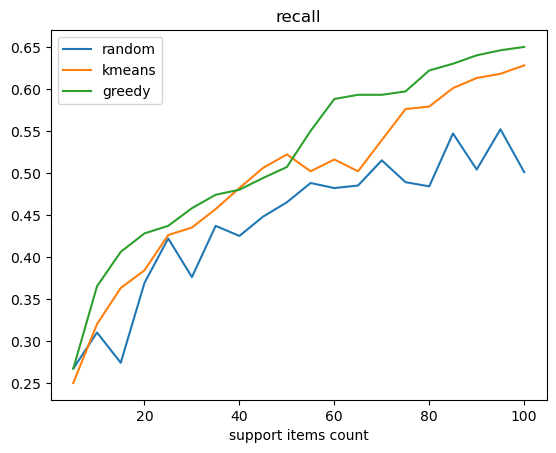

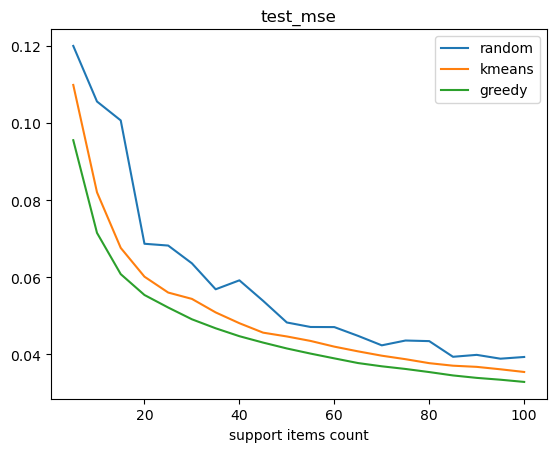

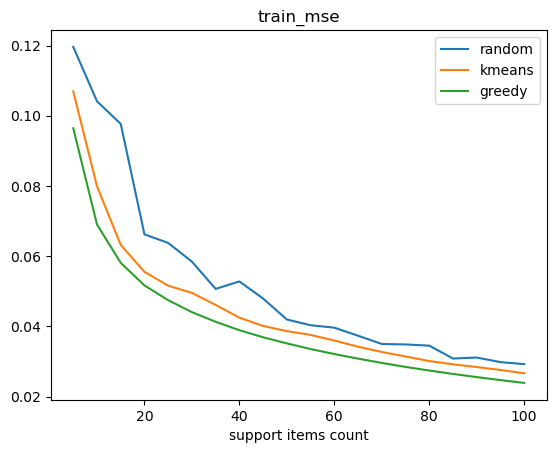

In [10]:
for metric in ["recall", "test_mse", "train_mse"]:
    plt.title(metric)
    plt.xlabel("support items count")
    for method in methods:
        plt.plot(item_cnt_range, stats[method][metric], label=method)
    plt.legend()
    plt.show()


In [11]:
index = item_cnt_range.index(100)
for m in methods:
    recall = stats[m]['recall'][index]
    std = np.sqrt(recall * (1 - recall) / test.shape[1])
    print(f"{m:<10} {recall:<6} +- {std:.3f}")

random     0.501  +- 0.016
kmeans     0.628  +- 0.015
greedy     0.65   +- 0.015
